## Decision Tree Classifier

A decision tree is a flowchart-like tree structure where an internal node represents a feature, the branch represents a decision rule, and each leaf node represents the outcome.

You do not need to standardize or normalize data for decision tree models. Decision trees are scale-invariant, meaning they make decisions based on the order of values rather than their absolute magnitude.

Tutorial guide: https://www.datacamp.com/tutorial/decision-tree-classification-python

In [29]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import random
import joblib

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.inspection import permutation_importance

RANDOM_SEED = 42
IMAGE_DIR = "../../results/images/DecisionTree"
DATASET_DIR = "../../data/processed/supervised/"

random.seed(RANDOM_SEED)
os.makedirs(IMAGE_DIR, exist_ok=True)

Read data

In [30]:
train_df = pd.read_csv(f'{DATASET_DIR}/train_data.csv')
val_df = pd.read_csv(f'{DATASET_DIR}/val_data.csv')
test_df = pd.read_csv(f'{DATASET_DIR}/test_data.csv')

In [31]:
X_train = train_df.drop('fraud', axis=1)
y_train = train_df['fraud']

X_val = val_df.drop('fraud', axis=1)
y_val = val_df['fraud']

X_test = test_df.drop('fraud', axis=1)
y_test = test_df['fraud']

### Build decision tree model
Random seach on Hyperparamters to find the best set

In [ ]:
seen = set()
results = []

while len(results) < 15:
    params = {
    "max_depth": random.choice([3, 5, 8, 10, 15, None]),
    "min_samples_split": random.choice([2, 5, 10, 20, 30]),
    "min_samples_leaf": random.choice([1, 2, 5, 10, 15])
    }

    key = tuple(params.items())
    if key in seen:
        continue
    seen.add(key)

    model = DecisionTreeClassifier(**params, random_state=RANDOM_SEED, class_weight={0: 1, 1: 10}, criterion="gini")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    probs_val = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    perc = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    
    roc_auc = roc_auc_score(y_val, probs_val)
    pr_auc = average_precision_score(y_val, probs_val)

    results.append({
        "params": params,
        "accuracy": acc,
        "precision": perc,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
        })

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="pr_auc", ascending=False)

results_df

,params,accuracy,precision,recall,f1_score,roc_auc,pr_auc
12,"{'max_depth': 8, 'min_samples_split': 5, 'min_...",0.994151,0.667416,0.928125,0.776471,0.986741,0.909328
10,"{'max_depth': 8, 'min_samples_split': 2, 'min_...",0.994162,0.668168,0.927083,0.776614,0.986213,0.908747
6,"{'max_depth': 5, 'min_samples_split': 30, 'min...",0.993911,0.654797,0.938542,0.771404,0.998582,0.894282
9,"{'max_depth': 5, 'min_samples_split': 20, 'min...",0.993911,0.654797,0.938542,0.771404,0.998582,0.894282
2,"{'max_depth': 5, 'min_samples_split': 5, 'min_...",0.993911,0.654797,0.938542,0.771404,0.998572,0.891388
8,"{'max_depth': None, 'min_samples_split': 30, '...",0.991916,0.582512,0.922917,0.714228,0.970012,0.883229
14,"{'max_depth': 10, 'min_samples_split': 2, 'min...",0.993615,0.644300,0.930208,0.761296,0.976181,0.876059
11,"{'max_depth': None, 'min_samples_split': 20, '...",0.994459,0.686321,0.909375,0.782258,0.960194,0.851990
5,"{'max_depth': 3, 'min_samples_split': 2, 'min_...",0.995006,0.715702,0.902083,0.798157,0.997690,0.826559
7,"{'max_depth': 3, 'min_samples_split': 30, 'min...",0.995006,0.715702,0.902083,0.798157,0.997690,0.826559


In [34]:
best_results = results_df.iloc[0]
best_params = best_results['params']

print("Validation Hyperparameters:", best_params)
print("Validation Accuracy:", best_results['accuracy'])
print("Validation Precision:", best_results['precision'])
print("Validation Recall:", best_results['recall'])
print("Validation F1 Score:", best_results['f1_score'])
print("Validation ROC AUC:", best_results['roc_auc'])
print("Validation PR AUC:", best_results['pr_auc'])

Validation Hyperparameters: {'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 2}
Validation Accuracy: 0.9941506465074913
Validation Precision: 0.6674157303370787
Validation Recall: 0.928125
Validation F1 Score: 0.7764705882352941
Validation ROC AUC: 0.986740990283446
Validation PR AUC: 0.9093284439351481


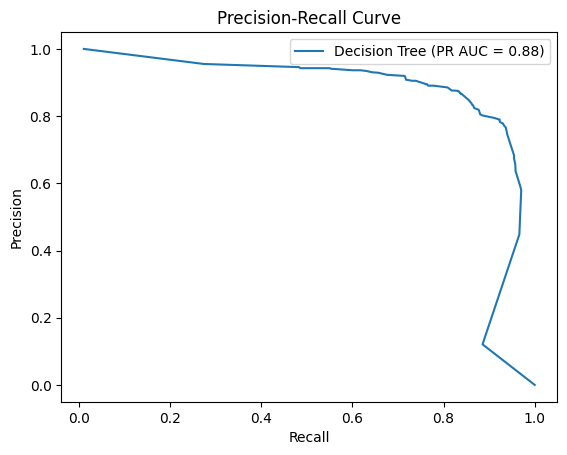

In [35]:
# Find where the model performs best on the validation set
precision, recall, thresholds = precision_recall_curve(y_val, probs_val)

plt.plot(precision, recall, label=f'Decision Tree (PR AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/pr_curve_validation.svg')
plt.show()

In [36]:
beta = 2    # Makes F2 score, puts more emphasis on recall
fbeta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-8)

best_idx = fbeta_scores.argmax()
best_threshold = thresholds[best_idx]

### Test on best performing model

In [ ]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train_val = train_val_df.drop('fraud', axis=1)
y_train_val = train_val_df['fraud']

model_final = DecisionTreeClassifier(
    class_weight={0: 1, 1: 10},
    random_state=RANDOM_SEED,
    criterion="gini",
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    min_samples_split=best_params["min_samples_split"]
)

model_final.fit(X_train_val, y_train_val)
joblib.dump({"model": model_final, "threshold": best_threshold}, '../../results/models/decision_tree.pkl')

probs = model_final.predict_proba(X_test)[:, 1]
y_test_pred = (probs > best_threshold).astype(int)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

roc_auc = roc_auc_score(y_test, y_test_pred)
pr_auc = average_precision_score(y_test, y_test_pred)

print("Test accuracy:", accuracy)
print("Test precision:", precision)
print("Test recall:", recall)
print("Test f1:", f1)
print("Test ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)

Test accuracy: 0.9960490723176905
Test precision: 0.7724014336917563
Test recall: 0.8979166666666667
Test f1: 0.8304431599229287
Test ROC AUC: 0.9475173293961021
Test PR AUC: 0.6946520948533355


### Tree Diagram

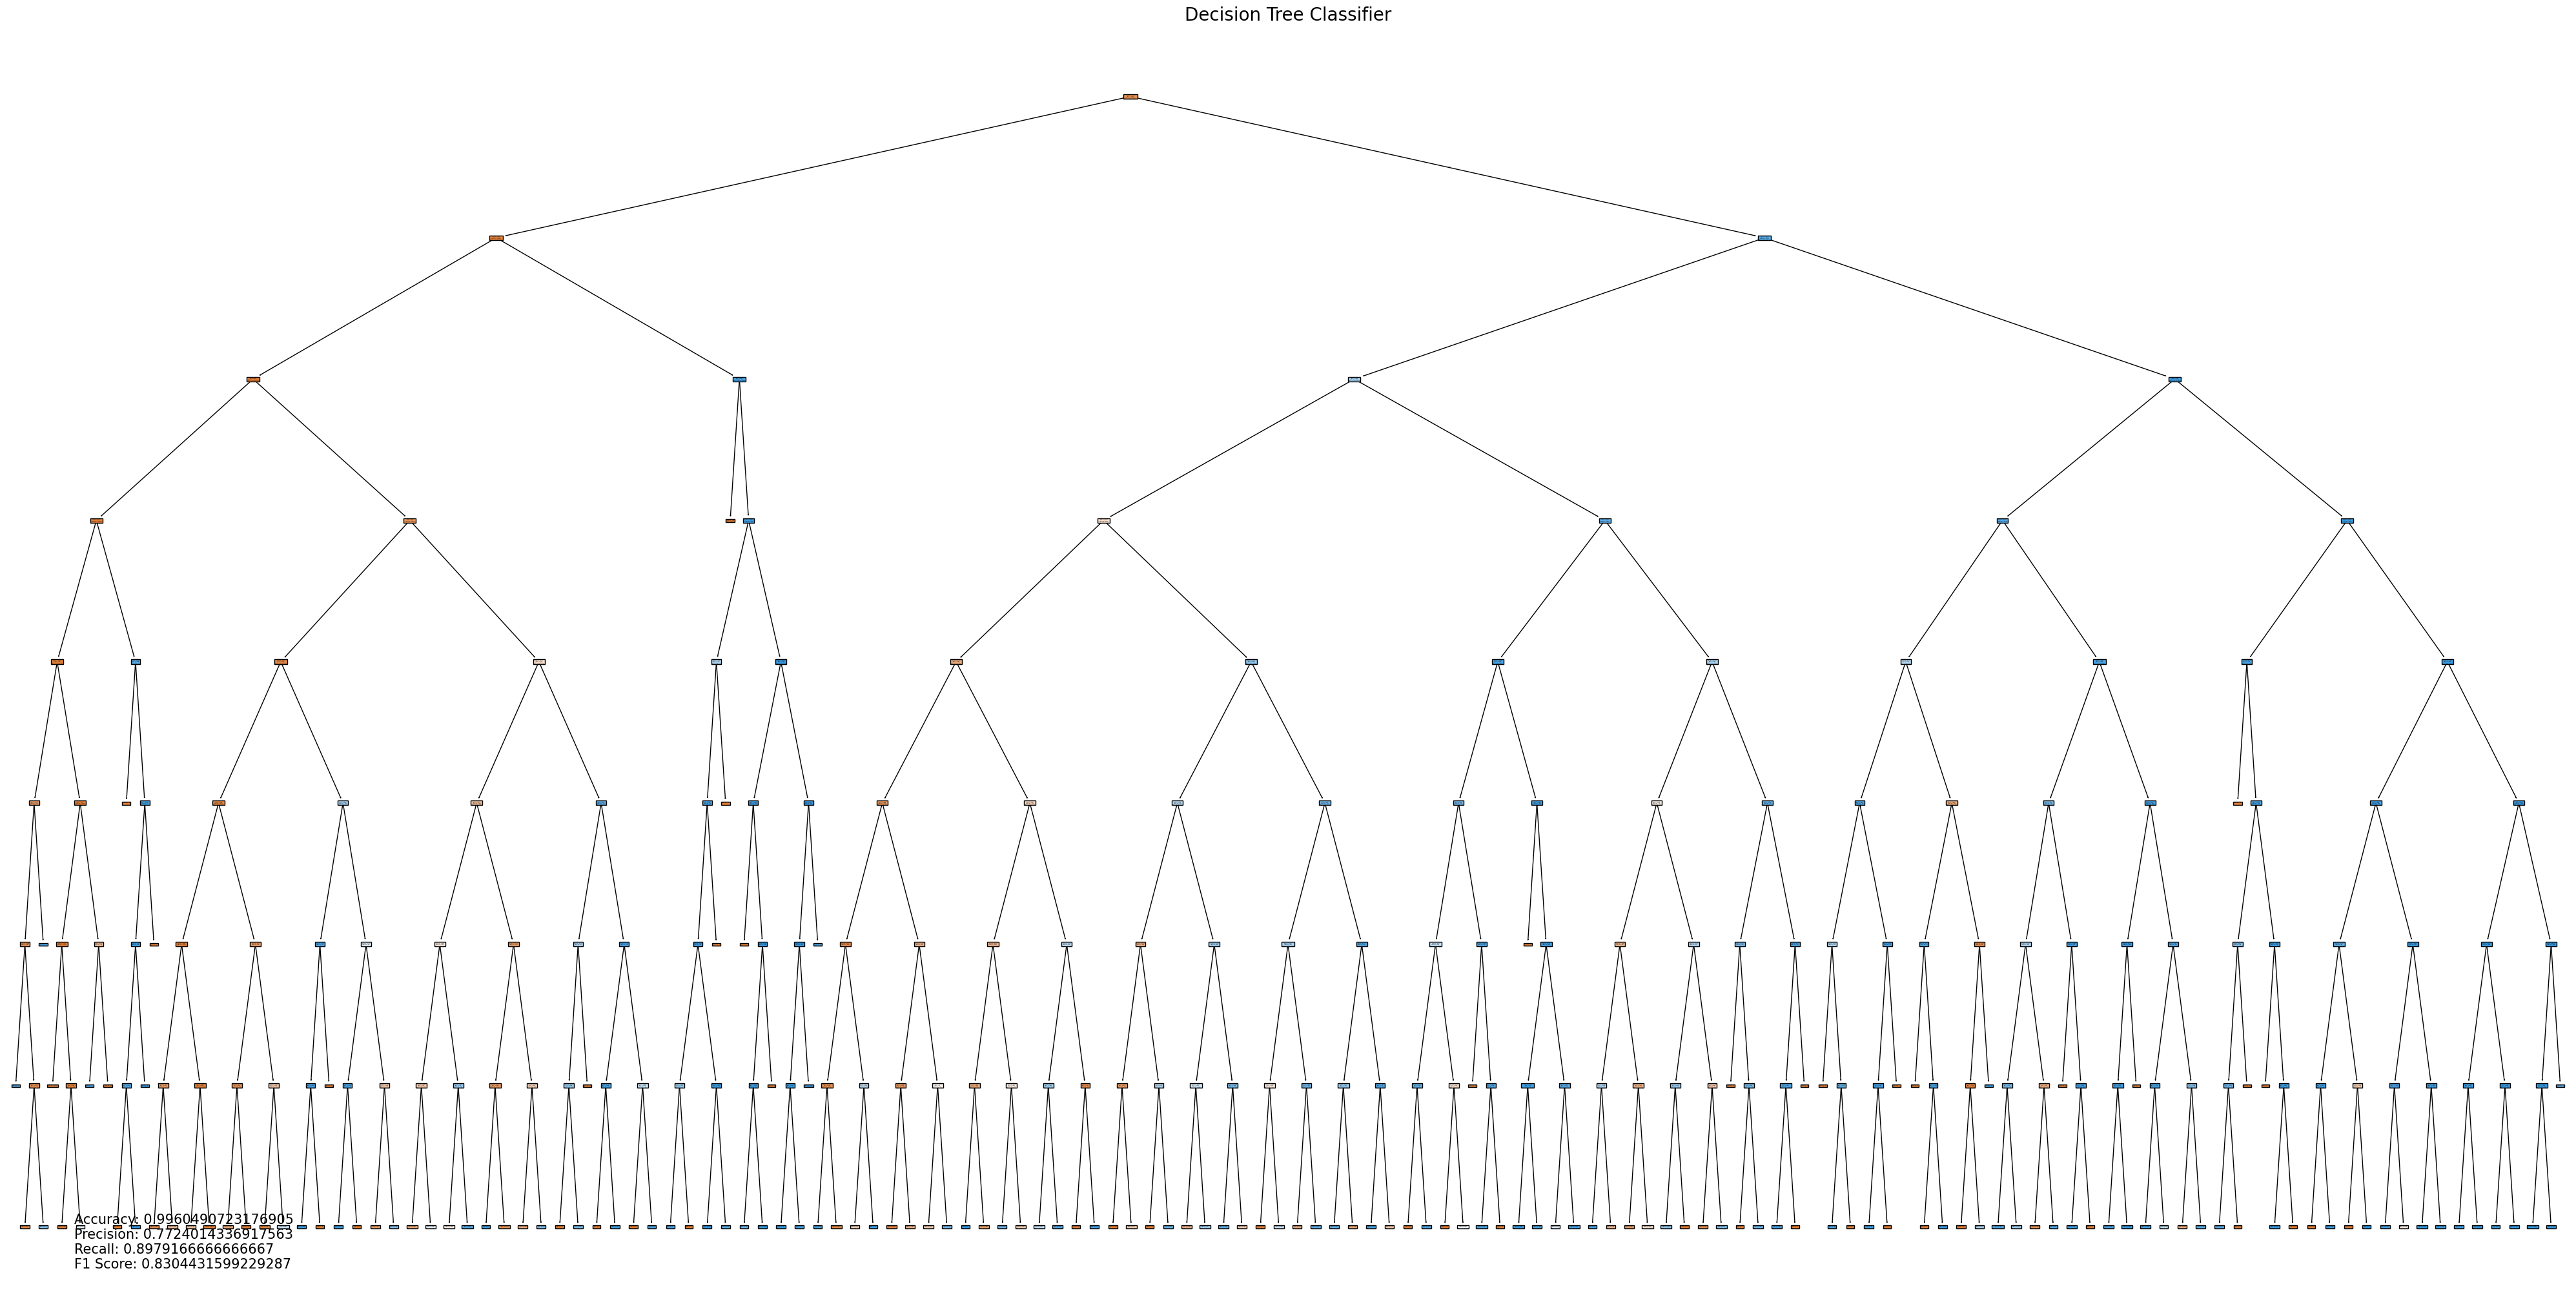

In [38]:
plt.figure(figsize=(40,20))
plot_tree(model_final, filled=True)
plt.tight_layout()
plt.title('Decision Tree Classifier', fontsize=20)
plt.figtext(0.03, 0.03, f'Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1 Score: {f1}', ha='left', fontsize=15)
plt.savefig(f'{IMAGE_DIR}/decision_tree.svg')
plt.show()

### Model Performance Visualisations

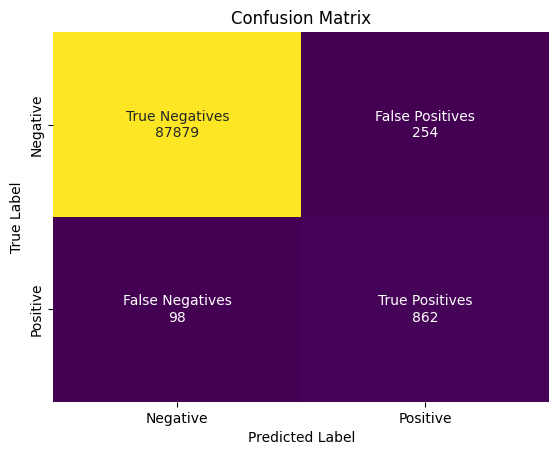

In [39]:
cf_matrix = confusion_matrix(y_test, y_test_pred)

group_names = ["True Negatives", "False Positives", "False Negatives", "True Positives"]

group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.array(labels).reshape(2,2)

matrix = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap="viridis", cbar=False)
matrix.set_xlabel("Predicted Label")
matrix.set_ylabel("True Label")
matrix.set_xticklabels(["Negative", "Positive"])
matrix.set_yticklabels(["Negative", "Positive"])
plt.title('Confusion Matrix')
plt.savefig(f'{IMAGE_DIR}/confusion_matrix.svg')
plt.show()

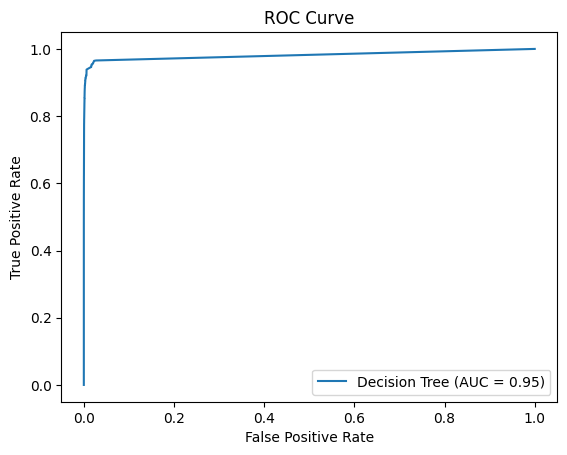

In [40]:
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/roc_curve_test.svg')
plt.show()


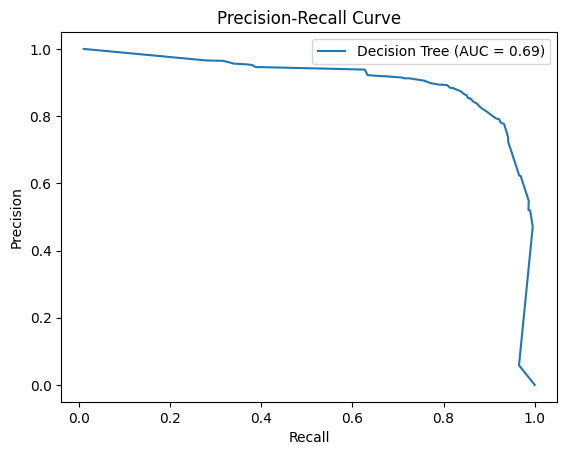

In [41]:
precision, recall, _ = precision_recall_curve(y_test, probs)

plt.plot(precision, recall, label=f'Decision Tree (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/pr_curve_test.svg')
plt.show()

### Feature Importance

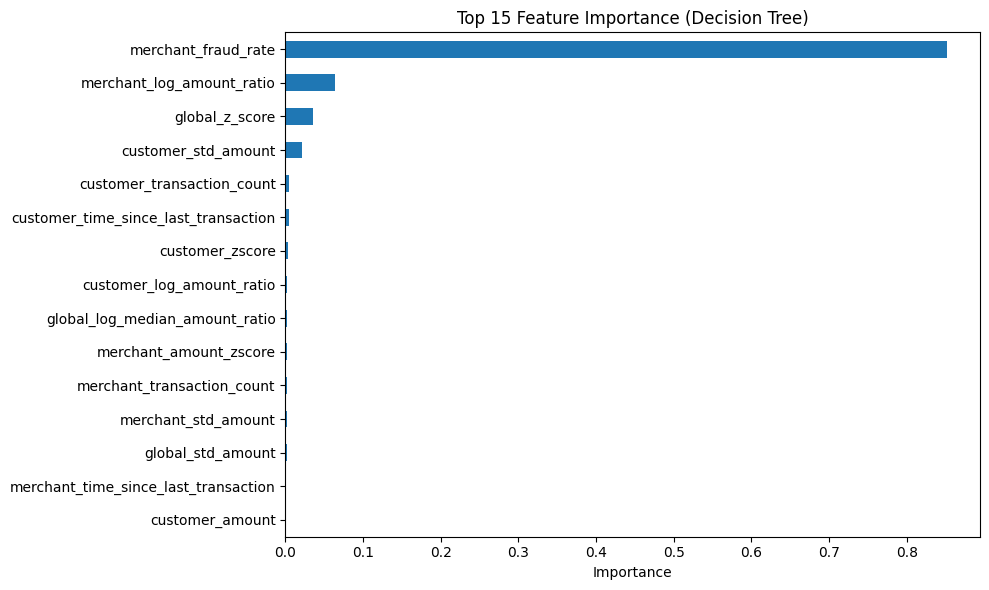

In [42]:
feat_imp = pd.Series(model_final.feature_importances_, index=X_train_val.columns)
feat_imp = feat_imp.sort_values(ascending=True)[15:]

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title("Top 15 Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/feature_importance.svg')
plt.show()

### Feature Permuatation
What features from training does the model consider would decrease/increase performance if they were removed

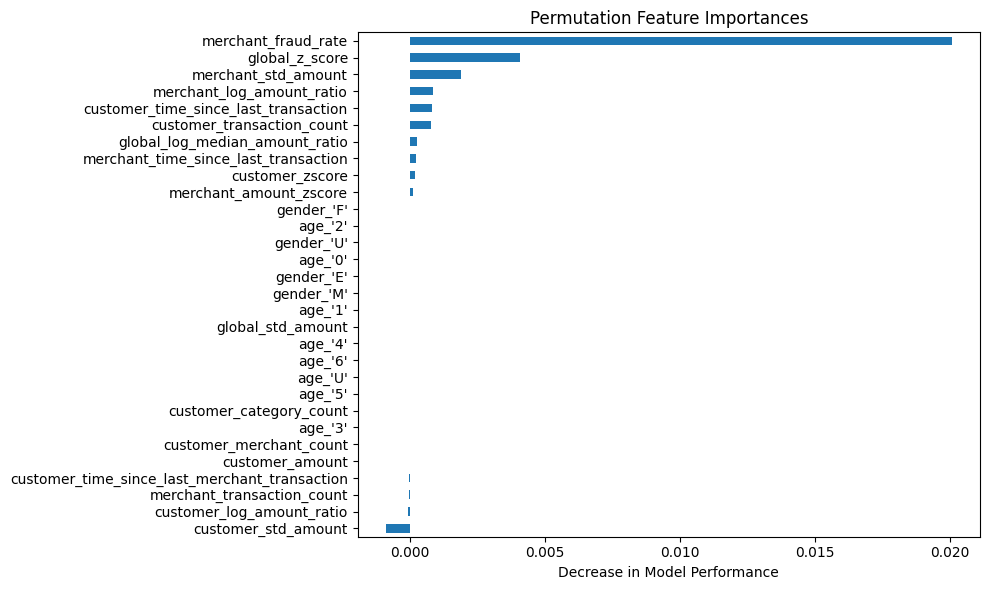

In [43]:
result = permutation_importance(
    model_final,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=X_train_val.columns)
perm_imp = perm_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_imp.sort_values().plot(kind='barh')
plt.title("Permutation Feature Importances")
plt.xlabel("Decrease in Model Performance")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/permutation_importance.svg')
plt.show()